# Train and serve a TensorFlow model with TensorFlow Serving

This Notebook showcases how Deep Learning can benefit from hybrid Cloud-HPC scenarios, in particular to offload the computationally demanding training phase to an HPC facility, and offering the resulting network as-a-Service on a Cloud architecture to answer time-constrained inference queries.

The notebook is a modified version of [this one](https://github.com/tensorflow/tfx/blob/master/docs/tutorials/serving/rest_simple.ipynb), which focuses mainly on Google Colab. Since we are not interested in pure performance for this use case, we use the small [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist) dataset and a very small custom Convolutional Neural Network (CNN).

The training phase has been offloaded to an HPC node on the [HPC4AI facility](https://hpc4ai.unito.it/), equipped with four NVIDIA Tesla V100 and two Intel Xeon Gols 6230 sockets. Then, the trained model is sent to a pre-existing TensorFlow Serving Pod on a Kubernetes cluster, hosted on the OpenStack-based  HPC4AI cloud.

Let's start with an import of all the required modules

In [1]:
print("test")

Serialize message LOG:name print value <built-in function print>
INSIDE POSTLOAD KERNEL 1
user ns 
{'print': <built-in function print>, '__name__': '__main__', '__builtin__': <module 'builtins' (built-in)>, '__builtins__': <module 'builtins' (built-in)>}
test


In [2]:
import sys

# Confirm that we're using Python 3
assert sys.version_info.major == 3, 'Oops, not running Python 3. Use Runtime > Change runtime type'

# TensorFlow and tf.keras
import tensorflow as tf
from tensorflow import keras

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt
import os
import subprocess

print('TensorFlow version: {}'.format(tf.__version__))

Serialize message LOG:name print value <built-in function print>
INSIDE POSTLOAD KERNEL 1
user ns 
{'print': <built-in function print>, '__name__': '__main__', '__builtin__': <module 'builtins' (built-in)>, '__builtins__': <module 'builtins' (built-in)>}
TensorFlow version: 2.19.0


Then we import the Fashion MNIST dataset, containing 70,000 grayscale images in 10 categories. The images show individual articles of clothing at low resolution (28 by 28 pixels), as seen here:

<table>
  <tr><td>
    <img src="https://tensorflow.org/images/fashion-mnist-sprite.png"
         alt="Fashion MNIST sprite"  width="600">
  </td></tr>
  <tr><td align="center">
    <b>Figure 1.</b> <a href="https://github.com/zalandoresearch/fashion-mnist">Fashion-MNIST samples</a> (by Zalando, MIT License).<br/>&nbsp;
  </td></tr>
</table>

Fashion MNIST is intended as a drop-in replacement for the classic [MNIST](http://yann.lecun.com/exdb/mnist/) dataset—often used as the "Hello, World" of machine learning programs for computer vision. You can access the Fashion MNIST directly from TensorFlow, just import and load the data.

In [3]:
# TensorFlow and tf.keras
import tensorflow as tf
from tensorflow import keras


fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# scale the values to 0.0 to 1.0
train_images = train_images / 255.0
test_images = test_images / 255.0

# reshape for feeding into the model
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1)
test_images = test_images.reshape(test_images.shape[0], 28, 28, 1)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print('\ntrain_images.shape: {}, of {}'.format(train_images.shape, train_images.dtype))
print('test_images.shape: {}, of {}'.format(test_images.shape, test_images.dtype))

Serialize message LOG:name print value <built-in function print>
INSIDE POSTLOAD KERNEL 1
INSIDE POSTLOAD KERNEL 1
INSIDE POSTLOAD KERNEL 1
INSIDE POSTLOAD KERNEL 1
INSIDE POSTLOAD KERNEL 1
INSIDE POSTLOAD KERNEL 1
user ns 
{'print': <built-in function print>, '__name__': '__main__', '__builtin__': <module 'builtins' (built-in)>, '__builtins__': <module 'builtins' (built-in)>}
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

train_images.shape: (60000, 28, 28, 1), of float64
test_images.shape: (10000, 28, 28, 1), of float64


At this point, we create our neural network model. Since we are not focused on performances, let's use the simplest possible CNN.

In [4]:
import tensorflow as tf
from tensorflow import keras


model = keras.Sequential([
  keras.layers.Conv2D(input_shape=(28,28,1), filters=8, kernel_size=3, 
                      strides=2, activation='relu', name='Conv1'),
  keras.layers.Flatten(),
  keras.layers.Dense(10, activation=tf.nn.softmax, name='Softmax')
])
model.summary()

INSIDE POSTLOAD KERNEL 1


2025-07-16 12:47:14.994730: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752670035.010099  177543 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752670035.014370  177543 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752670035.026881  177543 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752670035.026898  177543 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752670035.026901  177543 computation_placer.cc:177] computation placer alr

INSIDE POSTLOAD KERNEL
<Sequential name=sequential, built=True>
INSIDE POSTLOAD KERNEL 1
user ns 
{'__name__': '__main__', '__builtin__': <module 'builtins' (built-in)>, '__builtins__': <module 'builtins' (built-in)>}
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                  │ (None, 13, 13, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)             

Now we train the model for one epoch. Since this is commonly a computationally demanding step, we offload it to an HPC node through an SSH connector. For portability purposes, we execute the command on a Docker container on the remote environment, created from a standard `jupyter/tensorflow-notebook` image.

In order to replicate the experiment, you need to set the correct credentials in the Notebook metadata (e.g., `username` and `sshKey`) and, if necessary, modify the script template at `environment/hpc/ssh_template.jinja2`.

Please note that the TensorFlow network was not trivially serialisable by the `dill` engine, so we were forced to implement custom `predump` and `postload` directives to correctly handle the data transfer.

In [5]:
import tensorflow as tf
from tensorflow import keras


testing = False
epochs = 20

strategy = tf.distribute.MirroredStrategy()

with strategy.scope():
    model = tf.keras.models.clone_model(model)
    model.compile(optimizer='adam', 
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    model.fit(train_images, train_labels, epochs=epochs)
    test_loss, test_acc = model.evaluate(test_images, test_labels)
    
print('\nTest accuracy: {}'.format(test_acc))

Serialize message LOG:name model value <Sequential name=sequential, built=True>
Serialize message LOG:name train_images value [[[[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  ...

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]]


 [[[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  ...

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]]


 [[[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

 

At this point, the `model` variable contains the trained model's weights. To load our trained model into TensorFlow Serving we first need to save it in [SavedModel](https://www.tensorflow.org/versions/r1.15/api_docs/python/tf/saved_model) format.  This will create a protobuf file in a well-defined directory hierarchy, and will include a version number.

The path of the saved model is stored in the `export_path` variable to be easily referred to in the following cells.

In [6]:
import tempfile
import tensorflow as tf
from tensorflow import keras
import os

export_path = tempfile.mktemp(suffix='.keras')
print(f'Saving model to {export_path}…')

model.save(export_path)

print('\nSaved model:')
info = os.stat(export_path)
print(f'- Dimensione: {info.st_size} byte')
print(f'- Permessi: {oct(info.st_mode)}')
print(f'- Ultima modifica: {os.path.getmtime(export_path)}')


Serialize message LOG:name model value <Sequential name=sequential, built=True>
Serialize message LOG:name print value <built-in function print>
Serialize message LOG:name oct value <built-in function oct>
INSIDE POSTLOAD KERNEL 1
INSIDE POSTLOAD KERNEL 1
user ns 
{'model': <Sequential name=sequential, built=True>, 'print': <built-in function print>, 'oct': <built-in function oct>, '__name__': '__main__', '__builtin__': <module 'builtins' (built-in)>, '__builtins__': <module 'builtins' (built-in)>}
Saving model to /tmp/tmp5so8pfy9.keras…

Saved model:
- Dimensione: 71576 byte
- Permessi: 0o100644
- Ultima modifica: 1752670122.100886


In [7]:
#import tempfile
#import tensorflow as tf
#from tensorflow import keras
#!pip install ipython
#from IPython import get_ipython
#export_path = tempfile.mkdtemp()
#print('export_path = {}\n'.format(export_path))

#export_file = tempfile.mktemp(suffix='.keras')
#print(f'Saving model to {export_file}…')
#model.save(export_file)  # equivalente a keras.models.save_model
#tf.keras.models.save_model(
#    model,
#    export_path,
#    overwrite=True,
#    include_optimizer=True
#)

#print('\nSaved model:')
#!ls -l {export_path}
#!ls -l {export_file}
print("placeholder test")

Serialize message LOG:name model value <Sequential name=sequential, built=True>
Serialize message LOG:name print value <built-in function print>
INSIDE POSTLOAD KERNEL 1
user ns 
{'model': <Sequential name=sequential, built=True>, 'print': <built-in function print>, '__name__': '__main__', '__builtin__': <module 'builtins' (built-in)>, '__builtins__': <module 'builtins' (built-in)>}
placeholder test


At this point, we can send our model to a [TensorFlow Serving](https://www.tensorflow.org/tfx/guide/serving) instance for inference. We deploy a Kubernetes Pod containing a `tensorflow-serving` container, send the model folder as an input dependency and copy it on the `/models/model` path in the remote file-system, in order to start serving it.

In [8]:
#%%bash -s {export_path}
#rm -rf "/models/model"
#mkdir "/models/model"
#cp -r "$1" "/models/model/1"

import os
import shutil

src = export_path

dest_parent = "/models/model"

if os.path.exists(dest_parent):
    shutil.rmtree(dest_parent)

os.makedirs(dest_parent, exist_ok=True)

dest = os.path.join(dest_parent, "1")
if os.path.isdir(src):
    shutil.copytree(src, dest)
else:
    shutil.copy2(src, dest)

print(f"Modello copiato in {dest}")


Serialize message LOG:name export_path value /tmp/tmp5so8pfy9.keras
Serialize message LOG:name print value <built-in function print>
INSIDE POSTLOAD KERNEL 1
user ns 
{'export_path': '/tmp/tmp5so8pfy9.keras', 'print': <built-in function print>, '__name__': '__main__', '__builtin__': <module 'builtins' (built-in)>, '__builtins__': <module 'builtins' (built-in)>}
Modello copiato in /models/model/1


Now we can test if the inference server to test is actually able to correctly classify objects. Since the service is not publicly exposed, we use *Jupyter-workflow* to connect to the remote service and perform a local HTTP request to obtain the prediction.

In [9]:
#import json
#import requests

#data = json.dumps({"signature_name": "serving_default", "instances": test_images[0:3].tolist()})
#print('Data: {} ... {}'.format(data[:50], data[len(data)-52:]))

#headers = {"content-type": "application/json"}
#json_response = requests.post('http://localhost:8501/v1/models/model:predict', data=data, headers=headers)
#predictions = json.loads(json_response.text)['predictions']

import numpy as np
from tensorflow import keras


model = keras.models.load_model(export_path)



batch = test_images[0:3]  # shape: (3, altezza, larghezza, canali)

predictions = model.predict(batch)

print("Predictions shape:", predictions.shape)
print(predictions)


Serialize message LOG:name test_images value [[[[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  ...

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]]


 [[[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  ...

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]]


 [[[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  ...

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
  

Now we can show the prediction result locally on the Notebook, using `matplotlib`

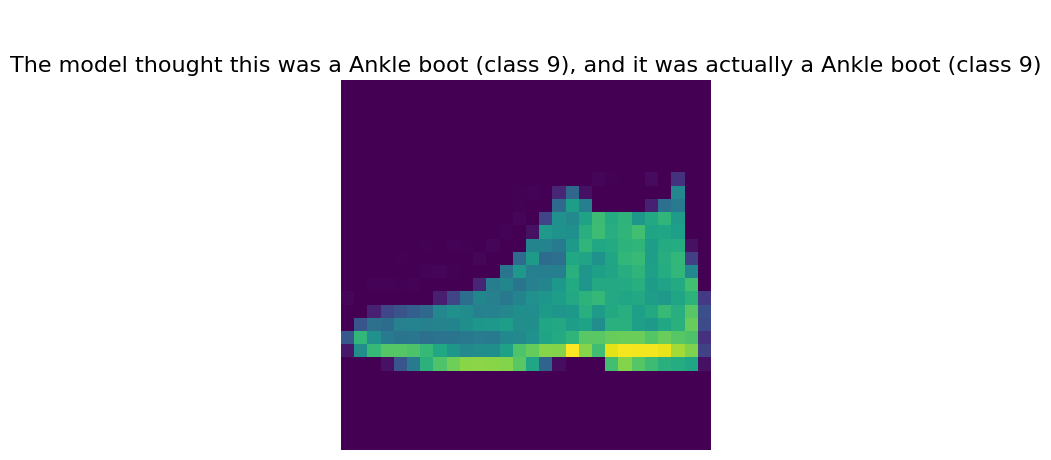

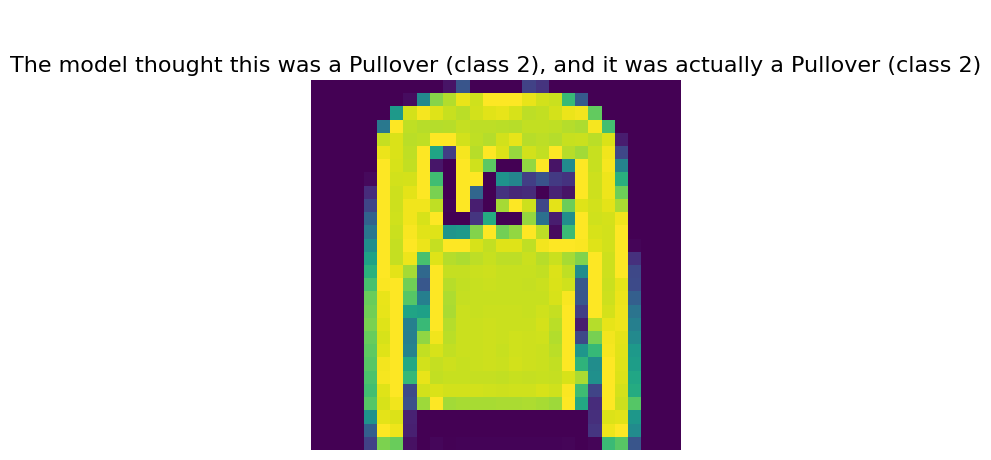

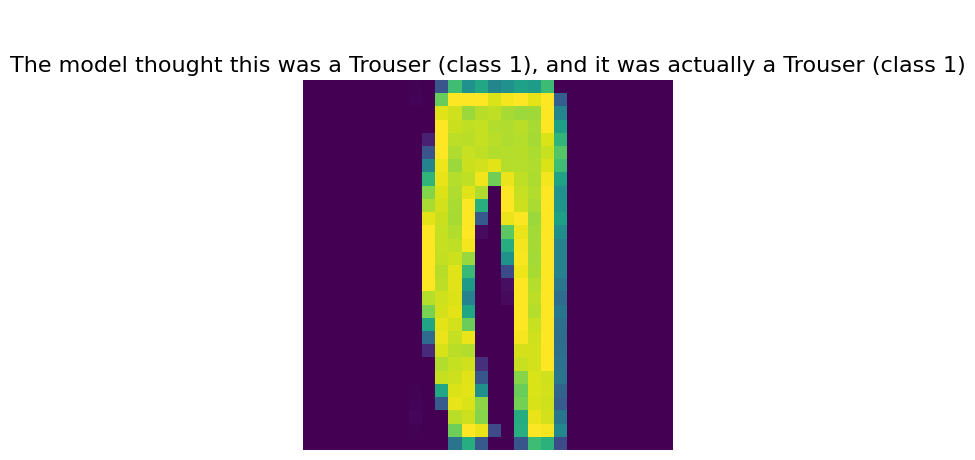

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def show(idx, title):
    plt.figure()
    plt.imshow(test_images[idx].reshape(28,28))
    plt.axis('off')
    plt.title('\n\n{}'.format(title), fontdict={'size': 16})

for index in range(3):
    show(index, 'The model thought this was a {} (class {}), and it was actually a {} (class {})'.format(
      class_names[np.argmax(predictions[index])], np.argmax(predictions[index]), class_names[test_labels[index]], test_labels[index]))

#for index in range(3):
#    plt.figure()
#    plt.imshow(test_images[index].reshape(28,28))
#    plt.axis('off')
#    plt.savefig(f'image_{index}.png')#
  #  print(f'\n\n\nINDEX {index}\n')

   # print(f'pred>{predictions[index]}\ntestlabels >{test_labels[0:3]}')

   # print(f'The model thought this was a {class_names[np.argmax(predictions[index])]} (class { np.argmax(predictions[index])}), and it was actually a { class_names[test_labels[index]]} (class { test_labels[index]})')